# Phillips Curve Test

Using `UNRATE.csv` and `CPIAUCSL.csv`, test the results of the Phillips curve over time.

**Question:** Does U.S. data show a negative relationship between inflation and unemployment,
and has that relationship held steady since 1949 or changed over time?

Three versions:
1. **Original Phillips curve:** inflation *level* vs. the unemployment rate.
2. **Expectations-augmented (accelerationist) curve:** *change* in inflation vs. unemployment.
   Under adaptive expectations, last year's inflation stands in for expected inflation.
3. **Stability over time:** does the slope change across monetary-policy eras?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Chart style: light grid, no top/right spines, consistent colors
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e5e5e5',
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
    'lines.linewidth': 2,
    'figure.dpi': 110,
})
BLUE = '#2a78d6'    # inflation / highlighted era
ORANGE = '#eb6834'  # unemployment
GRAY = '#b8b8b8'    # context points
INK = '#333333'     # fitted lines, annotations
SOURCE = 'Source: U.S. Bureau of Labor Statistics via FRED (CPIAUCSL, UNRATE).'

## 1. Load and merge

Both series are monthly from FRED. CPI starts in 1947-01 and unemployment in 1948-01. CPI inflation is
computed *before* merging so the extra 1947 CPI data can be used to build the 1948 inflation rate.

In [3]:
cpi = pd.read_csv('../CPIAUCSL.csv', parse_dates=['observation_date'], index_col='observation_date')['CPIAUCSL']
unrate = pd.read_csv('../UNRATE.csv', parse_dates=['observation_date'], index_col='observation_date')['UNRATE']

print('CPI    ', cpi.index[0].date(), '->', cpi.index[-1].date(), '|', len(cpi), 'months')
print('UNRATE ', unrate.index[0].date(), '->', unrate.index[-1].date(), '|', len(unrate), 'months')

CPI     1947-01-01 -> 2026-08-01 | 956 months
UNRATE  1948-01-01 -> 2026-08-01 | 944 months


In [4]:
# Missing values in either file?
print(cpi[cpi.isna()])
print(unrate[unrate.isna()])

observation_date
2025-10-01   NaN
Name: CPIAUCSL, dtype: float64
observation_date
2025-10-01   NaN
Name: UNRATE, dtype: float64


October 2025 is blank in both series. BLS did not publish data for that month, because of the fall 2025
federal government shutdown. That month is dropped below, so the 2025 annual average uses 11 months.

## 2. Build the variables

- `infl`: year-over-year CPI inflation, in percent. Using the change from 12 months earlier avoids the noise and seasonality of monthly changes.
- `d_infl`: the change in inflation over 12 months (this year's inflation minus last year's).
- `unrate_lag`: unemployment 12 months earlier, used as a robustness check.

In [5]:
infl = cpi.pct_change(12) * 100
d_infl = infl - infl.shift(12)

df = pd.concat({'CPIAUCSL': cpi, 'infl': infl, 'd_infl': d_infl, 'UNRATE': unrate}, axis=1, join='inner')
df['unrate_lag'] = df['UNRATE'].shift(12)

# d_infl needs 24 months of CPI history, so the sample starts in 1949-01
df = df.dropna(subset=['infl', 'd_infl', 'UNRATE'])
print('first', df.index[0].date(), '| last', df.index[-1].date(), '|', len(df), 'months')
df.head()

first 1949-01-01 | last 2026-08-01 | 931 months


,CPIAUCSL,infl,d_infl,UNRATE,unrate_lag
observation_date,,,,,
1949-01-01,24.01,1.393581,-8.848505,4.3,3.4
1949-02-01,23.91,1.013942,-8.468019,4.7,3.8
1949-03-01,23.91,1.744681,-5.073501,5.0,4.0
1949-04-01,23.92,0.419815,-7.852912,5.3,3.9
1949-05-01,23.91,-0.416493,-9.801459,6.1,3.5


## 3. Assign eras

| Era | Years | Why |
|---|---|---|
| Early postwar | 1949–1969 | Phillips (1958) and Samuelson–Solow (1960) era |
| Great Inflation | 1970–1984 | Oil shocks and the Volcker disinflation; the curve "breaks" |
| Great Moderation | 1985–2007 | Low, stable inflation |
| Post-GFC | 2008–2019 | The "flat" Phillips curve and the missing disinflation after the global financial crisis |
| Pandemic & after | 2020–2026 | Unemployment spike, then the 2021–23 inflation surge |

In [6]:
ERA_BINS = [1948, 1969, 1984, 2007, 2019, 2026]
ERAS = ['1949–1969', '1970–1984', '1985–2007', '2008–2019', '2020–2026']

df['era'] = pd.cut(df.index.year, bins=ERA_BINS, labels=ERAS)
df['era'].value_counts(sort=False)

era
1949–1969    252
1970–1984    180
1985–2007    276
2008–2019    144
2020–2026     79
Name: count, dtype: int64

In [7]:
# Annual averages, complete years only (2026 is partial; 2025 is missing October)
annual = df.loc['1949':'2025', ['infl', 'd_infl', 'UNRATE']].resample('YE').mean()
annual.index = annual.index.year
annual['era'] = pd.cut(annual.index, bins=ERA_BINS, labels=ERAS)
annual.tail()

,infl,d_infl,UNRATE,era
observation_date,,,,
2021,4.676517,3.421638,5.350000,2020–2026
2022,7.998426,3.321909,3.650000,2020–2026
2023,4.146104,-3.852321,3.625000,2020–2026
2024,2.954308,-1.191796,4.025000,2020–2026
2025,2.691925,-0.296516,4.263636,2020–2026


## 4. Describe the data

In [8]:
# Mean and volatility of inflation and unemployment by era
df.groupby('era', observed=True)[['infl', 'UNRATE']].agg(['mean', 'std']).round(2)

infl       UNRATE      
           mean   std   mean   std
era                               
1949–1969  2.05  2.12   4.71  1.22
1970–1984  7.24  3.19   6.92  1.55
1985–2007  3.05  1.07   5.61  0.99
2008–2019  1.77  1.30   6.44  2.09
2020–2026  3.90  2.24   4.78  2.07

In [9]:
# Correlation between inflation and unemployment: full sample and within each era
corr = df.groupby('era', observed=True).apply(lambda d: d['infl'].corr(d['UNRATE']))
corr['Full sample'] = df['infl'].corr(df['UNRATE'])
corr.round(2).to_frame('corr(infl, UNRATE)')

,"corr(infl, UNRATE)"
era,
1949–1969,-0.50
1970–1984,-0.10
1985–2007,0.08
2008–2019,-0.13
2020–2026,-0.51
Full sample,0.08


In [10]:
# 10-year (120-month) rolling correlation, for Figure 5
rolling_corr = df['infl'].rolling(120).corr(df['UNRATE']).dropna()
print('most negative:', round(rolling_corr.min(), 2), 'in the 10 years ending', rolling_corr.idxmin().strftime('%b %Y'))
print('most positive:', round(rolling_corr.max(), 2), 'in the 10 years ending', rolling_corr.idxmax().strftime('%b %Y'))

most negative: -0.82 in the 10 years ending Aug 1969
most positive: 0.55 in the 10 years ending Oct 1975


## 5. Figures

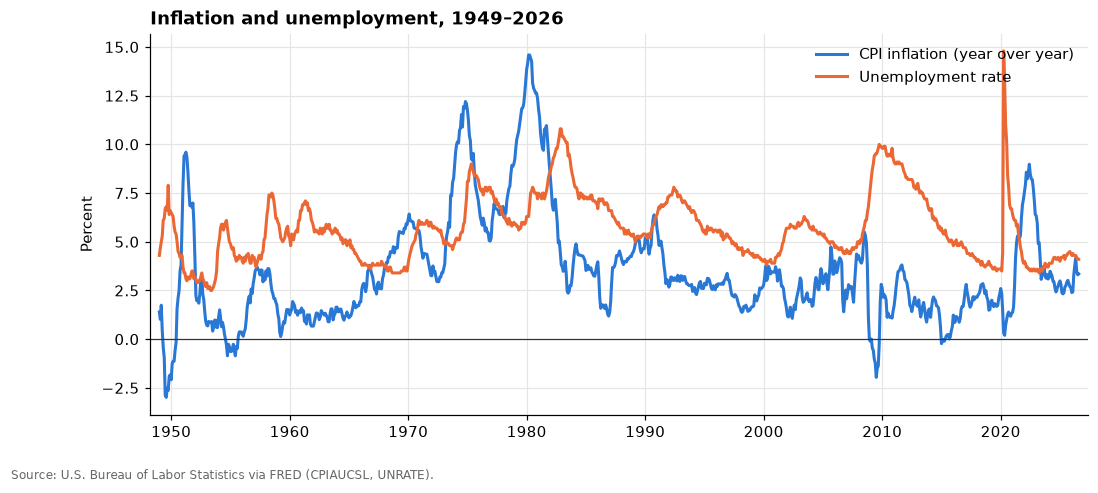

In [11]:
# Figure 1: inflation and unemployment over time (both in percent, so one axis)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df.index, df['infl'], color=BLUE, label='CPI inflation (year over year)')
ax.plot(df.index, df['UNRATE'], color=ORANGE, label='Unemployment rate')
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_ylabel('Percent')
ax.set_title('Inflation and unemployment, 1949–2026', loc='left', fontweight='bold')
ax.legend(frameon=False, loc='upper right')
ax.margins(x=0.01)
fig.text(0.01, -0.02, SOURCE, fontsize=8, color='#666666')
plt.show()

### A helper for fitting a line

`fit()` runs a simple OLS regression of `y` on `x` with `np.polyfit`. It returns the slope `b`, intercept `a`,
R², number of observations, and the implied NAIRU `u* = -a/b`. The NAIRU is only meaningful when the slope is
negative, so it is left blank otherwise.

In [12]:
def fit(d, x, y):
    d = d[[x, y]].dropna()
    b, a = np.polyfit(d[x], d[y], 1)
    r2 = d[x].corr(d[y]) ** 2
    u_star = -a / b if b < 0 else np.nan
    return pd.Series({'slope b': b, 'intercept a': a, 'R²': r2, 'N': len(d), 'implied u*': u_star})

def fit_by_era(d, x, y):
    table = d.groupby('era', observed=True).apply(lambda g: fit(g, x, y))
    table.loc['Full sample'] = fit(d, x, y)
    table['N'] = table['N'].astype(int)
    return table.round(2)

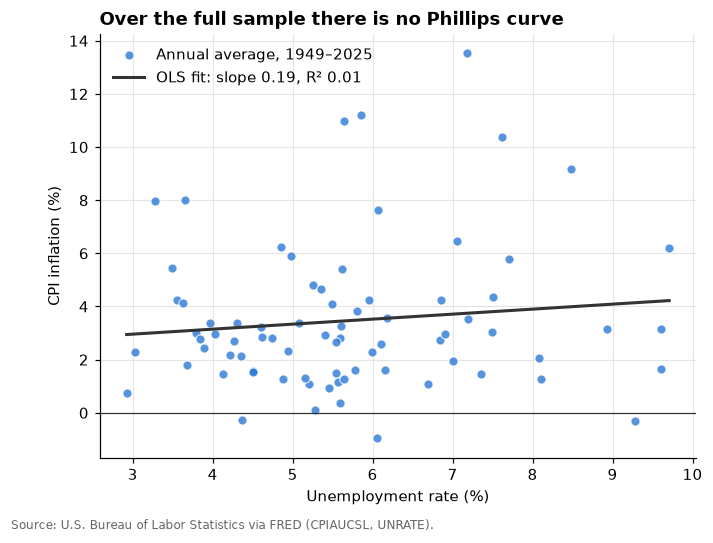

In [13]:
# Figure 2: full-sample scatter (annual), original Phillips curve
res = fit(annual, 'UNRATE', 'infl')
xs = np.linspace(annual['UNRATE'].min(), annual['UNRATE'].max(), 50)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(annual['UNRATE'], annual['infl'], s=36, color=BLUE, alpha=0.8, edgecolor='white', linewidth=0.8, label='Annual average, 1949–2025')
ax.plot(xs, res['intercept a'] + res['slope b'] * xs, color=INK, label=f"OLS fit: slope {res['slope b']:.2f}, R² {res['R²']:.2f}")
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_xlabel('Unemployment rate (%)')
ax.set_ylabel('CPI inflation (%)')
ax.set_title('Over the full sample there is no Phillips curve', loc='left', fontweight='bold')
ax.legend(frameon=False)
fig.text(0.01, -0.02, SOURCE, fontsize=8, color='#666666')
plt.show()

In [14]:
# Small-multiples helper: one panel per era, that era's years in blue over all years in gray
def era_panels(y, ylabel, title, show_nairu=False):
    fig, axes = plt.subplots(1, len(ERAS), figsize=(15, 4), sharex=True, sharey=True)
    for ax, era in zip(axes, ERAS):
        sub = annual[annual['era'] == era]
        res = fit(sub, 'UNRATE', y)
        xs = np.linspace(sub['UNRATE'].min(), sub['UNRATE'].max(), 50)
        ax.scatter(annual['UNRATE'], annual[y], s=18, color=GRAY, alpha=0.5, linewidth=0)
        ax.scatter(sub['UNRATE'], sub[y], s=36, color=BLUE, edgecolor='white', linewidth=0.8)
        ax.plot(xs, res['intercept a'] + res['slope b'] * xs, color=INK)
        ax.axhline(0, color=INK, linewidth=0.8)
        if show_nairu and not np.isnan(res['implied u*']) and 3 < res['implied u*'] < 10:
            ax.axvline(res['implied u*'], color=INK, linestyle=':', linewidth=1.2)
        ax.set_title(f"{era}\nslope {res['slope b']:.2f}, R² {res['R²']:.2f}", fontsize=10)
        ax.set_xlabel('Unemployment (%)')
    axes[0].set_ylabel(ylabel)
    fig.suptitle(title, x=0.01, ha='left', fontweight='bold')
    fig.text(0.01, -0.04, SOURCE + ' Annual averages. Gray = all years; blue = the panel\'s era.', fontsize=8, color='#666666')
    fig.tight_layout()
    plt.show()

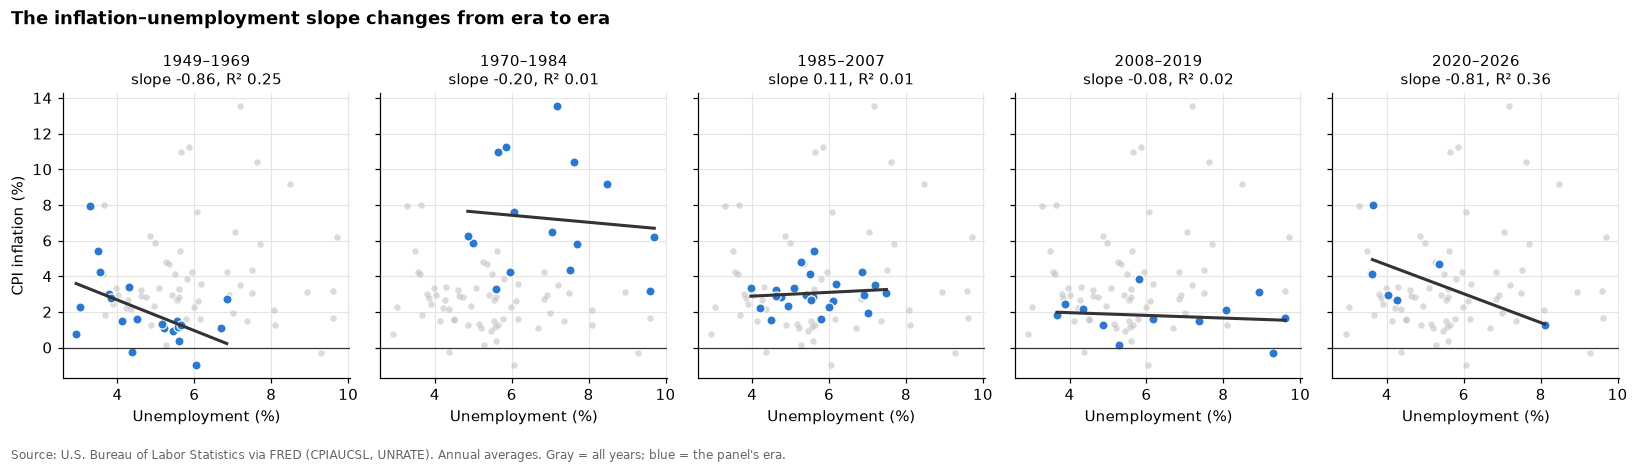

In [15]:
# Figure 3: original Phillips curve by era (the key figure)
era_panels('infl', 'CPI inflation (%)', 'The inflation–unemployment slope changes from era to era')

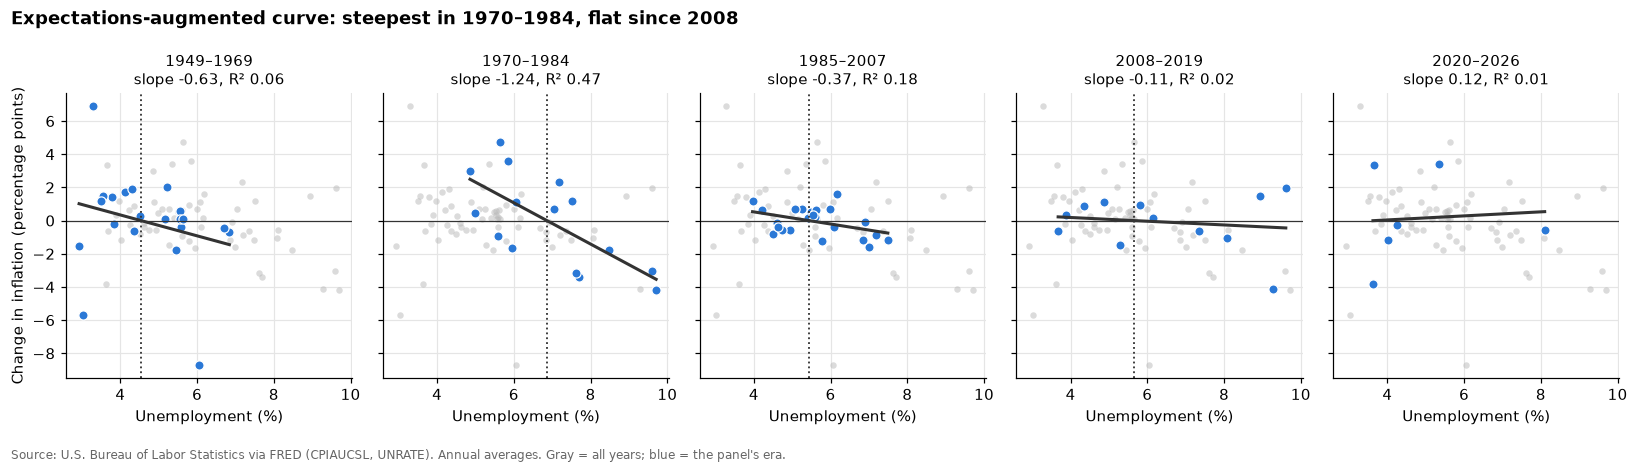

In [16]:
# Figure 4: expectations-augmented curve by era. The dotted line marks the implied NAIRU (where Δ inflation = 0)
era_panels('d_infl', 'Change in inflation (percentage points)', 'Expectations-augmented curve: steepest in 1970–1984, flat since 2008', show_nairu=True)

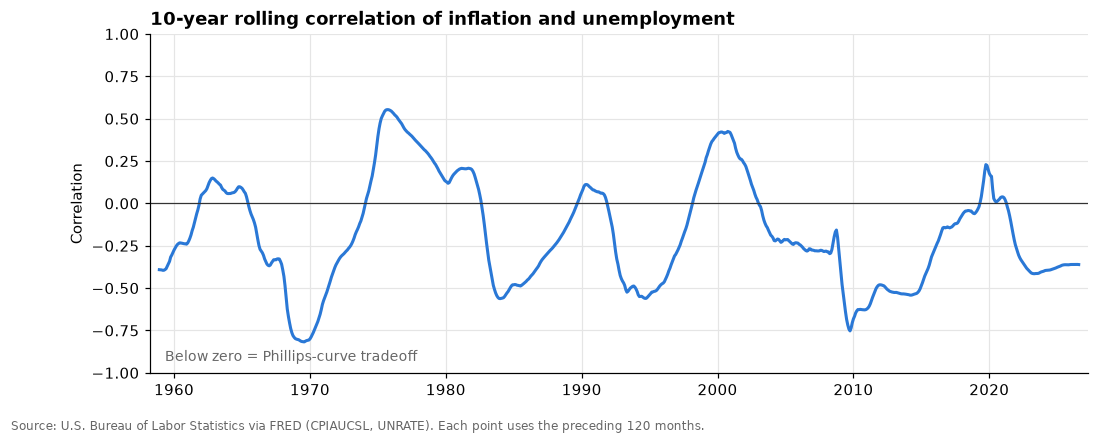

In [17]:
# Figure 5: 10-year rolling correlation between inflation and unemployment
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rolling_corr.index, rolling_corr, color=BLUE)
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_ylim(-1, 1)
ax.set_ylabel('Correlation')
ax.set_title('10-year rolling correlation of inflation and unemployment', loc='left', fontweight='bold')
ax.text(rolling_corr.index[5], -0.93, 'Below zero = Phillips-curve tradeoff', fontsize=9, color='#666666')
ax.margins(x=0.01)
fig.text(0.01, -0.02, SOURCE + ' Each point uses the preceding 120 months.', fontsize=8, color='#666666')
plt.show()

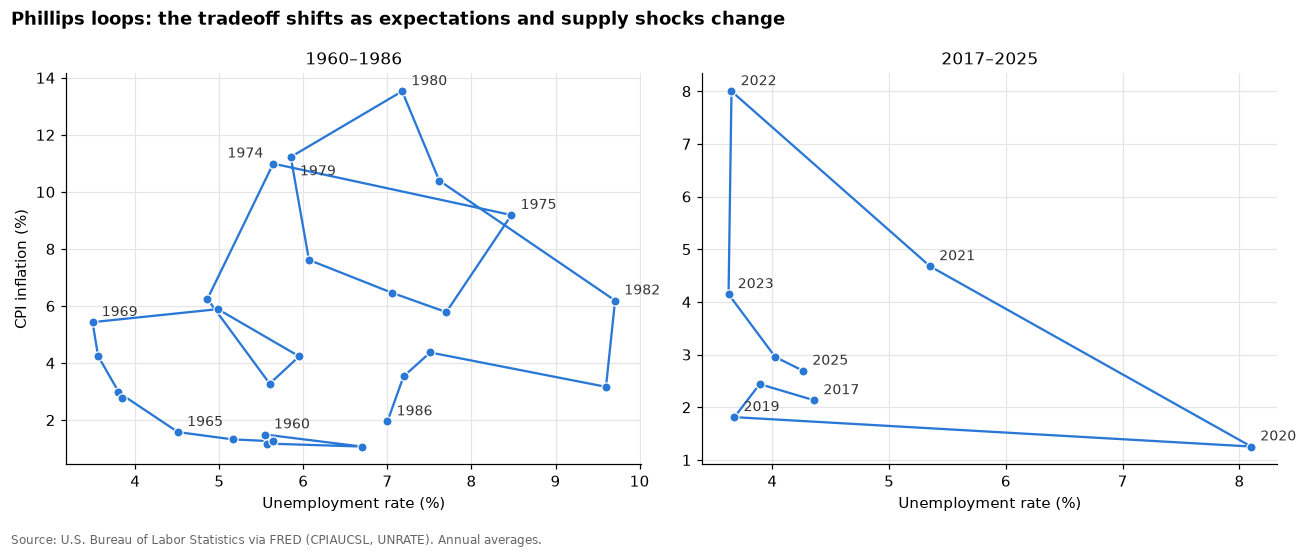

In [18]:
# Figure 6: Phillips "loops" - the path of (unemployment, inflation) year by year
def loop(ax, start, end, label_years, offsets={}):
    sub = annual.loc[start:end]
    ax.plot(sub['UNRATE'], sub['infl'], color=BLUE, linewidth=1.5, marker='o', markersize=6,
            markeredgecolor='white', markeredgewidth=0.8)
    for yr in label_years:
        ax.annotate(str(yr), (sub.loc[yr, 'UNRATE'], sub.loc[yr, 'infl']),
                    xytext=offsets.get(yr, (6, 4)), textcoords='offset points', fontsize=9, color=INK)
    ax.set_title(f'{start}–{end}', fontsize=11)
    ax.set_xlabel('Unemployment rate (%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
loop(axes[0], 1960, 1986, [1960, 1965, 1969, 1974, 1975, 1979, 1980, 1982, 1986],
     offsets={1974: (-30, 4), 1979: (6, -12)})
loop(axes[1], 2017, 2025, [2017, 2019, 2020, 2021, 2022, 2023, 2025])
axes[0].set_ylabel('CPI inflation (%)')
fig.suptitle('Phillips loops: the tradeoff shifts as expectations and supply shocks change', x=0.01, ha='left', fontweight='bold')
fig.text(0.01, -0.03, SOURCE + ' Annual averages.', fontsize=8, color='#666666')
fig.tight_layout()
plt.show()

## 6. Estimate

Simple OLS on the monthly data:
- **Model A (original):** `infl_t = a + b·UNRATE_t`
- **Model B (expectations-augmented):** `Δinfl_t = a + b·UNRATE_t`, with implied NAIRU `u* = -a/b`

A Phillips curve shows up as **b < 0**.

In [19]:
# The implied u* only applies to Model B, so it is dropped here
model_a = fit_by_era(df, 'UNRATE', 'infl').drop(columns='implied u*')
model_a

,slope b,intercept a,R²,N
era,,,,
1949–1969,-0.87,6.16,0.25,252
1970–1984,-0.21,8.71,0.01,180
1985–2007,0.08,2.59,0.01,276
2008–2019,-0.08,2.30,0.02,144
2020–2026,-0.55,6.54,0.26,79
Full sample,0.13,2.73,0.01,931


In [20]:
model_b = fit_by_era(df, 'UNRATE', 'd_infl')
model_b

,slope b,intercept a,R²,N,implied u*
era,,,,,
1949–1969,-0.70,3.18,0.07,252,4.56
1970–1984,-1.24,8.53,0.43,180,6.86
1985–2007,-0.37,1.99,0.09,276,5.43
2008–2019,-0.12,0.71,0.02,144,5.73
2020–2026,-0.06,0.50,0.00,79,7.80
Full sample,-0.37,2.06,0.06,931,5.52


In [21]:
# Side-by-side summary
summary = pd.concat({'Model A: inflation': model_a[['slope b', 'R²']],
                     'Model B: Δ inflation': model_b[['slope b', 'R²', 'implied u*']]}, axis=1)
summary['N'] = model_a['N']
summary

Model A: inflation       Model B: Δ inflation                   \
                       slope b    R²              slope b    R² implied u*   
era                                                                          
1949–1969                -0.87  0.25                -0.70  0.07       4.56   
1970–1984                -0.21  0.01                -1.24  0.43       6.86   
1985–2007                 0.08  0.01                -0.37  0.09       5.43   
2008–2019                -0.08  0.02                -0.12  0.02       5.73   
2020–2026                -0.55  0.26                -0.06  0.00       7.80   
Full sample               0.13  0.01                -0.37  0.06       5.52   

               N  
                  
era               
1949–1969    252  
1970–1984    180  
1985–2007    276  
2008–2019    144  
2020–2026     79  
Full sample  931

## 7. Robustness

1. **Monthly vs. annual:** do the slopes agree when estimated on annual averages?
2. **Drop the COVID spike:** exclude April–December 2020, when unemployment briefly hit 14.8%.
3. **Lagged unemployment:** use unemployment 12 months earlier in place of current unemployment.

In [22]:
no_covid = df.drop(df.loc['2020-04':'2020-12'].index)

robust = pd.DataFrame({
    'A: monthly': model_a['slope b'],
    'A: annual': fit_by_era(annual, 'UNRATE', 'infl')['slope b'],
    'A: no COVID': fit_by_era(no_covid, 'UNRATE', 'infl')['slope b'],
    'A: lagged u': fit_by_era(df, 'unrate_lag', 'infl')['slope b'],
    'B: monthly': model_b['slope b'],
    'B: annual': fit_by_era(annual, 'UNRATE', 'd_infl')['slope b'],
    'B: no COVID': fit_by_era(no_covid, 'UNRATE', 'd_infl')['slope b'],
    'B: lagged u': fit_by_era(df, 'unrate_lag', 'd_infl')['slope b'],
})
robust

,A: monthly,A: annual,A: no COVID,A: lagged u,B: monthly,B: annual,B: no COVID,B: lagged u
era,,,,,,,,
1949–1969,-0.87,-0.86,-0.87,-0.18,-0.70,-0.63,-0.70,0.76
1970–1984,-0.21,-0.20,-0.21,-0.63,-1.24,-1.24,-1.24,-0.64
1985–2007,0.08,0.11,0.08,0.06,-0.37,-0.37,-0.37,-0.10
2008–2019,-0.08,-0.08,-0.08,0.01,-0.12,-0.11,-0.12,0.14
2020–2026,-0.55,-0.81,-0.95,0.44,-0.06,0.12,1.20,0.91
Full sample,0.13,0.19,0.18,0.19,-0.37,-0.35,-0.39,0.10


## 8. Write-up

**Is there a stable Phillips curve?** No, not over the full sample. From 1949 to 2026, inflation and unemployment are essentially uncorrelated (r = 0.08), and the Model A slope is slightly *positive* (0.13, R² 0.01). Figure 2 shows a cloud of points, not a downward-sloping line. The relationship exists in some eras, though, and the version that works best changes over time.

**1949–1969: the textbook curve.** This is the period Phillips and Samuelson–Solow were describing, and the data fit it. Each extra point of unemployment is associated with about 0.9 pp lower inflation (R² 0.25). The 10-year rolling correlation bottoms out at −0.82 in the decade ending August 1969, the strongest tradeoff in the sample.

**1970–1984: the curve breaks, and the Friedman–Phelps critique fits.** Inflation and unemployment both rose (stagflation). The level relationship almost vanishes (slope −0.21, R² 0.01), and the rolling correlation turns *positive*, peaking at +0.55 in the decade ending October 1975. The expectations-augmented Model B, however, fits this era better than any other model in the notebook: slope −1.24, R² 0.43, implied NAIRU about 6.9%. That is what Friedman (1968) and Phelps (1967) predicted. Once people expect inflation, the tradeoff is between unemployment and *changes* in inflation, and pushing unemployment below the natural rate buys ever-rising inflation rather than a permanently higher level. The loop in Figure 6 shows the curve shifting up through the 1970s, then the Volcker disinflation (1980–1982) buying lower inflation with roughly 10% unemployment.

**1985–2007: weak, but the accelerationist version survives.** Model A is flat (0.08). Model B is still negative (−0.37; R² 0.09 monthly, 0.18 annual), with an implied NAIRU of about 5.4%, lower than in the 1970s.

**2008–2019: the flat Phillips curve.** Both models are close to zero (slopes −0.08 and −0.12, R² ≤ 0.02). Unemployment reached 10% in 2009–2010, yet inflation never turned into sustained deflation. This is the "missing disinflation," commonly explained by well-anchored inflation expectations after decades of credible Fed policy.

**2020–2026: a steep curve again, or supply shocks?** The level relationship comes back (Model A slope −0.55, R² 0.26; −0.95 without the April–December 2020 COVID months), driven by 8% inflation in 2022 at 3.6% unemployment. Model B, however, is flat and unstable: its slope swings from −0.06 to +1.20 when the COVID months are dropped. With only 79 months, dominated by one shock, this era is hard to read. The 2021–2023 surge is consistent with a *nonlinear* curve that steepens when the labor market is very tight. It is equally consistent with supply shocks (supply chains, energy, reopening demand) that a curve with unemployment as its only input cannot separate from demand pressure.

**Robustness.** Monthly and annual estimates agree closely in every era except 2020–2026. Dropping the COVID months matters only for 2020–2026. Using unemployment from 12 months earlier weakens or flips most slopes, so the relationship in this data is mostly contemporaneous.

**Limitations.**
- Headline CPI includes food and energy, so supply shocks (1973–74, 1979, 2021–22) enter inflation directly. Core CPI would be a cleaner test.
- There is no direct data on expectations. Last year's inflation is a crude proxy, and it becomes a poorer one once expectations are anchored.
- The 12-month changes overlap and are highly autocorrelated, so the monthly N overstates the independent information. No standard errors are reported for that reason, and R² should be read as descriptive.
- Simultaneity: the Fed responds to inflation by raising rates, which raises unemployment, so OLS slopes mix the Phillips curve with the policy reaction.
- The era cutoffs are chosen, not estimated, and the NAIRU is assumed constant within each era. An implied u* is only meaningful where Model B's slope is clearly negative (1970–1984 and 1985–2007), not where the fit is flat (2008–2019, 2020–2026).

**Bottom line.** The simple inflation–unemployment tradeoff held only in the 1950s–60s and briefly in the 2020s. The expectations-augmented version fits best when inflation expectations were moving (the 1970s) and fades when they are anchored (after 2008). The data support Friedman–Phelps over a stable, exploitable Phillips curve.